In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("seaborn-v0_8")

In [3]:
df = pd.read_csv(
    r"C:\Users\r8885426\OneDrive - FRG\Documents\G4L\cpi_data_cleaned.csv"
)

cpi_weight = pd.read_excel(
    r"C:\Users\r8885426\OneDrive - FRG\Documents\G4L\cpi_weights.xlsx"
)





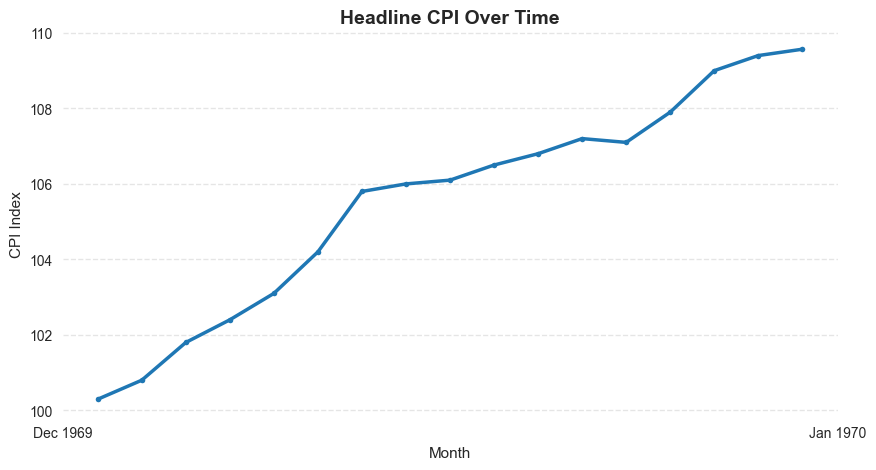

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Filter Headline CPI
headline = df[df["Category"] == "Headline_CPI"]

# Style
sns.set_style("whitegrid")

plt.figure(figsize=(10, 5))

# Plot line
plt.plot(
    headline["Month"],
    headline["Value"],
    linewidth=2.5,
    color="#1f77b4",
    marker="o",
    markersize=4
)

# Titles & labels
plt.title("Headline CPI Over Time", fontsize=14, weight="bold")
plt.xlabel("Month", fontsize=11)
plt.ylabel("CPI Index", fontsize=11)

# Format x-axis to show fewer dates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Clean up grid
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.grid(False, axis="x")



In [5]:
cpi_weight.columns

Index(['Category', 'Weight'], dtype='str')

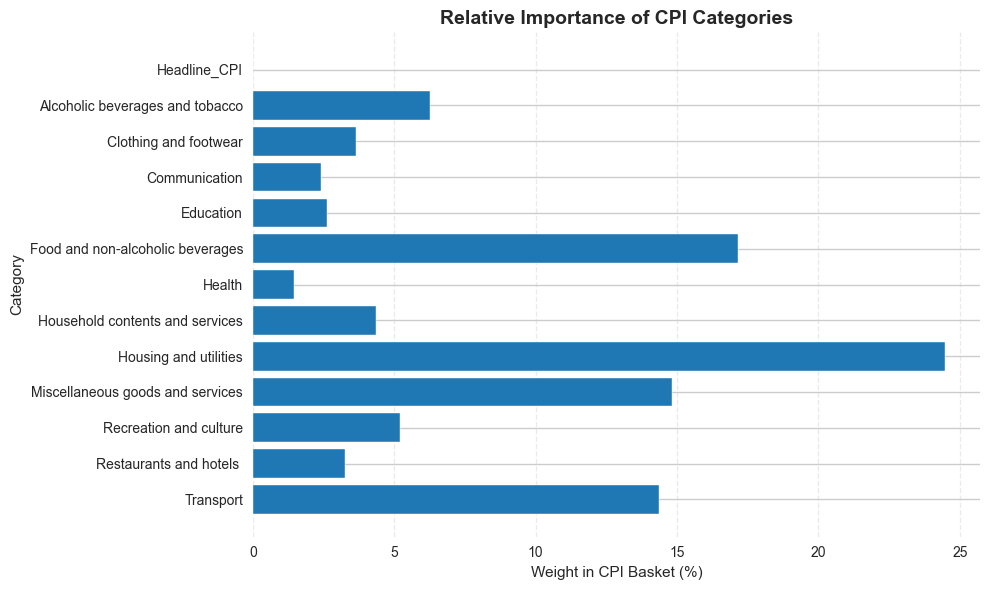

In [6]:
plt.figure(figsize=(10, 6))

plt.barh(
    cpi_weight["Category"],
    cpi_weight["Weight"],
    color="#1f77b4"
)

plt.xlabel("Weight in CPI Basket (%)", fontsize=11)
plt.ylabel("Category", fontsize=11)
plt.title(
    "Relative Importance of CPI Categories",
    fontsize=14,
    weight="bold"
)

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


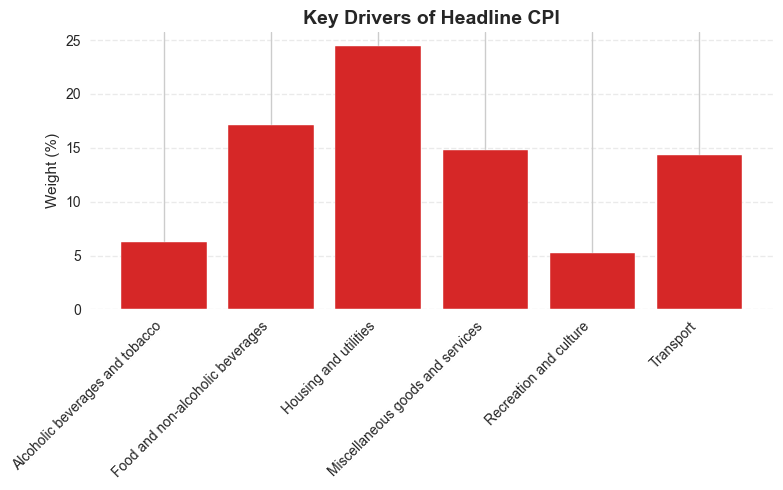

In [7]:
# Focus on categories with meaningful weight (e.g. ≥ 5%)
top_weights = cpi_weight[cpi_weight["Weight"] >= 5]

plt.figure(figsize=(8, 5))

plt.bar(
    top_weights["Category"],
    top_weights["Weight"],
    color="#d62727"
)

plt.ylabel("Weight (%)", fontsize=11)
plt.title(
    "Key Drivers of Headline CPI",
    fontsize=14,
    weight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


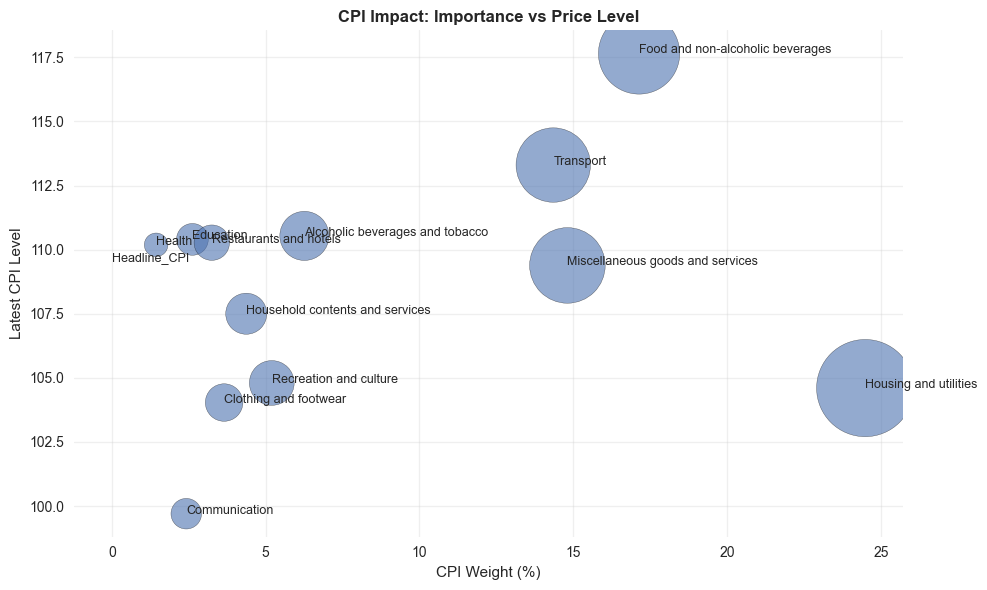

In [8]:
# Merge latest CPI with weights
latest_cpi = (
    df.sort_values("Month")
      .groupby("Category")
      .last()
      .reset_index()
)

bubble_df = latest_cpi.merge(cpi_weight, on="Category", how="inner")

plt.figure(figsize=(10,6))
plt.scatter(
    bubble_df["Weight"],
    bubble_df["Value"],
    s=bubble_df["Weight"] * 200,
    alpha=0.6,
    edgecolors="black"
)

for _, row in bubble_df.iterrows():
    plt.text(row["Weight"], row["Value"], row["Category"], fontsize=9)

plt.xlabel("CPI Weight (%)")
plt.ylabel("Latest CPI Level")
plt.title("CPI Impact: Importance vs Price Level", weight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


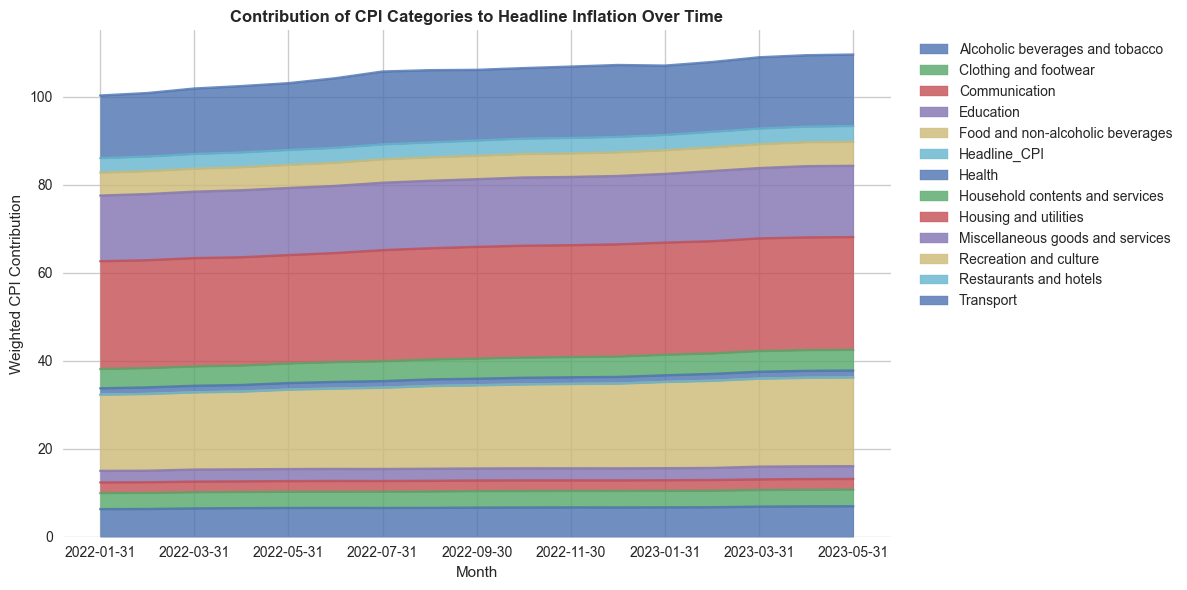

In [9]:
weighted_cpi = df.merge(cpi_weight, on="Category")
weighted_cpi["Weighted_Value"] = weighted_cpi["Value"] * weighted_cpi["Weight"] / 100

pivot_stack = weighted_cpi.pivot(
    index="Month",
    columns="Category",
    values="Weighted_Value"
)

pivot_stack.plot(
    kind="area",
    figsize=(12,6),
    alpha=0.8
)

plt.title("Contribution of CPI Categories to Headline Inflation Over Time", weight="bold")
plt.ylabel("Weighted CPI Contribution")
plt.xlabel("Month")
plt.legend(bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()


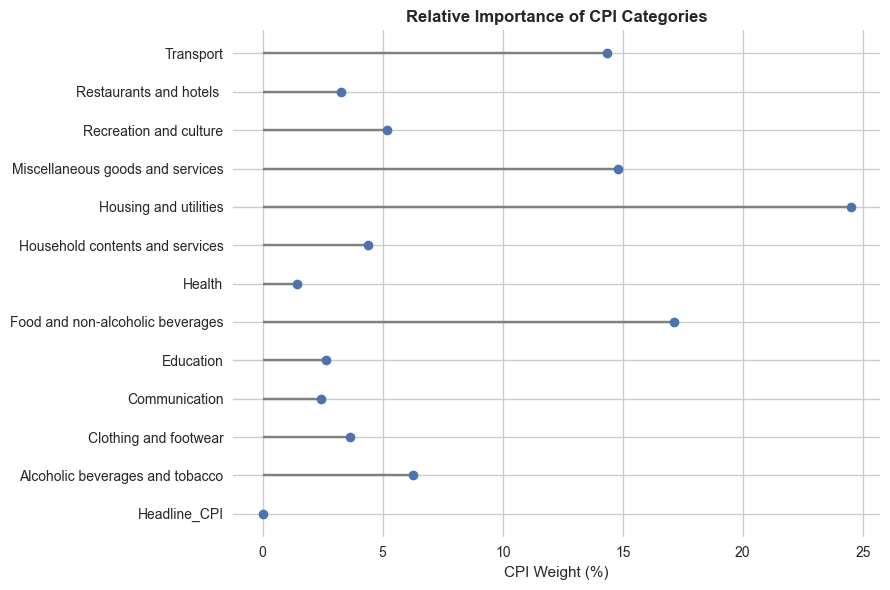

In [10]:
plt.figure(figsize=(9,6))

plt.hlines(
    y=cpi_weight["Category"],
    xmin=0,
    xmax=cpi_weight["Weight"],
    color="grey"
)
plt.plot(
    cpi_weight["Weight"],
    cpi_weight["Category"],
    "o"
)

plt.xlabel("CPI Weight (%)")
plt.title("Relative Importance of CPI Categories", weight="bold")
plt.tight_layout()
plt.show()
